<a href="https://colab.research.google.com/github/MiguelPastorB/pastorbeltra/blob/main/Bernoulli.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Esto de abajo habrá que cambiarlo para ejecutarlo en local, tal y como está en bandit_experiment.ipynb

In [ ]:
import numpy as np
import random
import sys
import os

# Añadimos la carpeta 'src' al path de búsqueda de Python
sys.path.append(os.path.abspath('src'))

from src.algorithms.algorithm import Algorithm
from src.algorithms.epsilon_greedy import EpsilonGreedy, DecayingEpsilonGreedy
from src.algorithms.ucb1 import UCB1
from src.algorithms.softmax import Softmax
from src.arms.arm import Arm
from src.arms.armnormal import ArmNormal
from src.arms.bandit import Bandit
from src.arms.armbinomial import ArmBinomial
from src.plotting.plotting import plot_average_rewards, plot_optimal_selections, plot_regret

seed = 2024
np.random.seed(seed)
random.seed(seed)

In [31]:
def run_experiment(algorithms, n_arms, n_steps, n_runs):
    # Matrices para almacenar resultados: (algoritmos x pasos) [cite: 314-315]
    all_rewards = np.zeros((len(algorithms), n_steps))
    optimal_counts = np.zeros((len(algorithms), n_steps))
    regret_accumulated = np.zeros((len(algorithms), n_steps))

    # Definimos las probabilidades reales de los brazos (Bernoulli)
    # n=1 convierte la Binomial en Bernoulli [cite: 396, 402]
    probs = np.linspace(0.1, 0.9, n_arms) 
    optimal_arm_idx = np.argmax(probs)
    max_mu = probs[optimal_arm_idx]

    for run in range(n_runs):
        # Reiniciamos brazos para cada run [cite: 386, 469]
        # Usamos ArmBinomial con n=1 para simular Bernoulli [cite: 402]
        arms = [ArmBinomial(n=1, p=p) for p in probs]
        bandit = Bandit(arms)
        
        # Reiniciamos algoritmos (estado inicial) para garantizar independencia [cite: 469]
        for alg in algorithms:
            alg.reset() 

        for step in range(n_steps):
            for i, alg in enumerate(algorithms):
                # 1. El agente elige brazo según su política [cite: 372-373]
                arm_idx = alg.select_arm()
                
                # 2. El entorno devuelve recompensa [cite: 374]
                reward = bandit.pull_arm(arm_idx)
                
                # 3. El agente aprende actualizando sus estimaciones [cite: 332, 491]
                alg.update(arm_idx, reward)
                
                # Guardamos métricas brutas
                all_rewards[i, step] += reward
                if arm_idx == optimal_arm_idx:
                    optimal_counts[i, step] += 1
                
                # Calculamos regret instantáneo (R(T) = mu* - mu_elegido) [cite: 379-381, 384]
                current_regret = max_mu - probs[arm_idx]
                regret_accumulated[i, step] += current_regret

    # Promediamos resultados por el número de runs para suavizar curvas [cite: 315]
    avg_rewards = all_rewards / n_runs
    avg_optimal = (optimal_counts / n_runs) * 100 # En porcentaje [cite: 412, 415]
    avg_regret = np.cumsum(regret_accumulated / n_runs, axis=1) # Acumulado temporalmente [cite: 379, 419]

    # Ahora retornamos las tres métricas para tus gráficas
    return avg_rewards, avg_optimal, avg_regret

In [ ]:
n_arms = 10
n_steps = 1000
n_runs = 2000 # Un número alto garantiza rigor metodológico

# Lista de algoritmos a comparar
all_algorithms = [
    EpsilonGreedy(k=n_arms, epsilon=0.1),
    DecayingEpsilonGreedy(k=n_arms), # Variante recomendada [cite: 459]
    UCB1(k=n_arms),
    Softmax(k=n_arms, temperature=0.1)
]

# Ejecutamos
avg_rewards, opt_selections, regret_data = run_experiment(all_algorithms, n_arms, n_steps, n_runs)

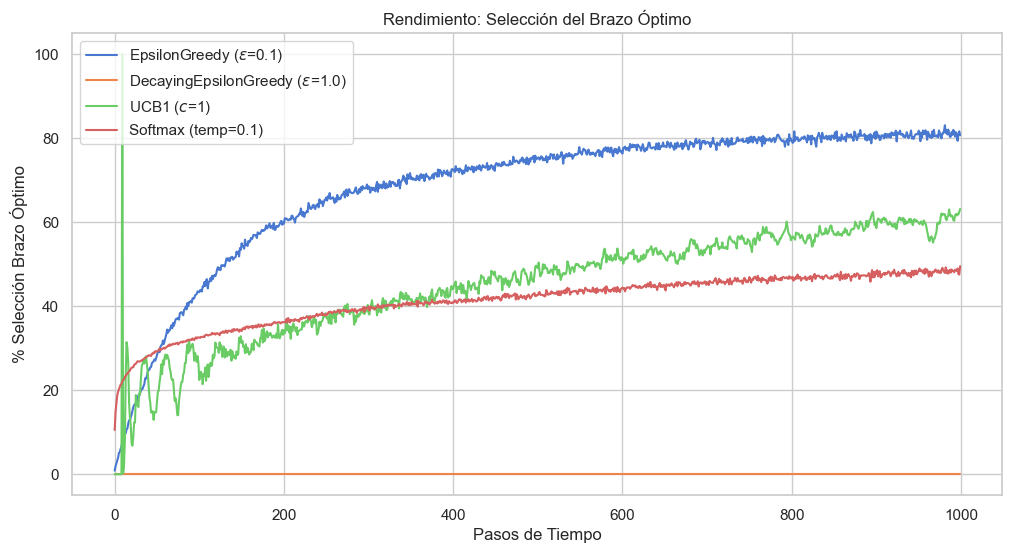

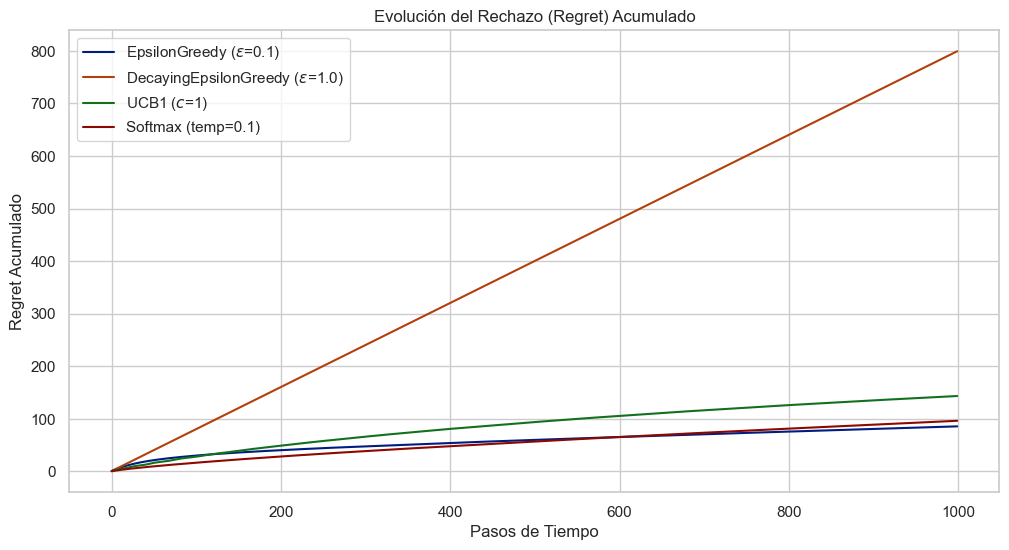

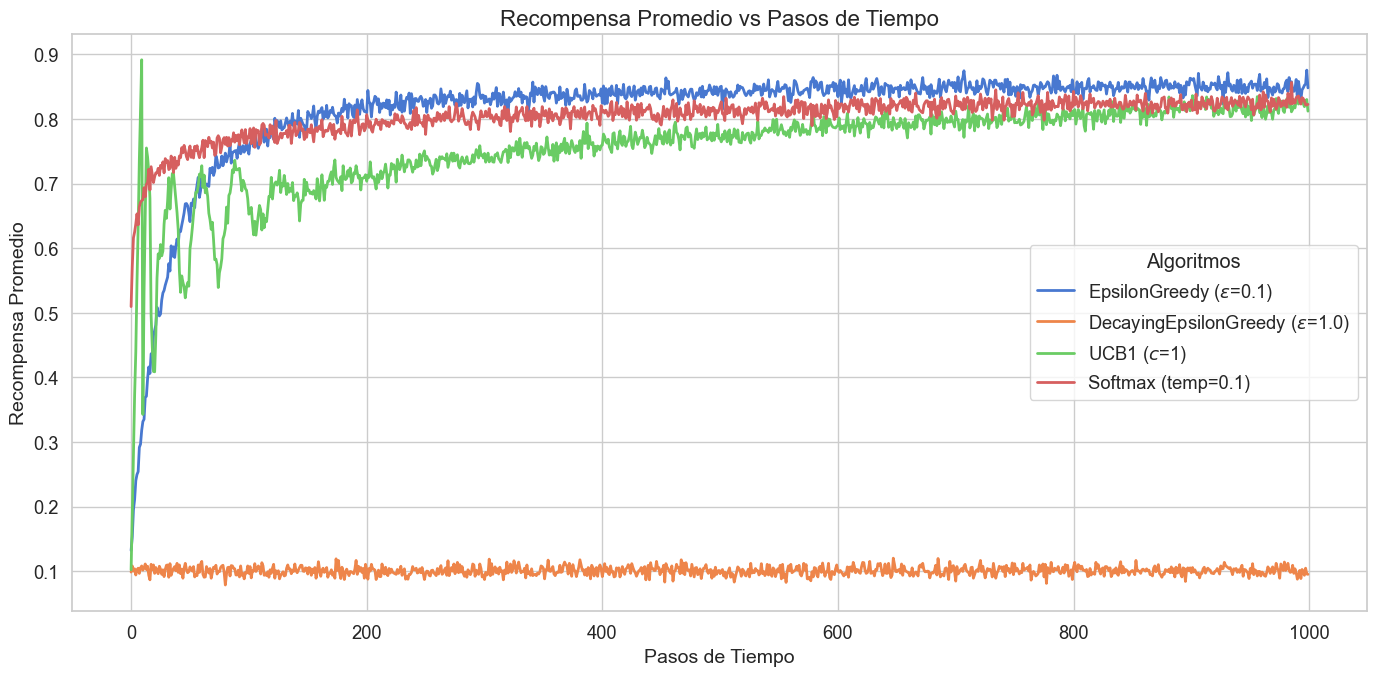

In [ ]:
# Gráfica 1: % de Selección del Brazo Óptimo
plot_optimal_selections(n_steps, opt_selections, all_algorithms)

# Gráfica 2: Regret Acumulado
plot_regret(n_steps, regret_data, all_algorithms)

# Gráfica 3: Recompensa Promedio
plot_average_rewards(n_steps, avg_rewards, all_algorithms)